# nanoGPT From Scratch — Watch a Transformer *Learn*

**The leap from `../attention-transformer`:** that notebook showed the transformer
*forward* pass — the mechanism. Here we add the two things that turn a mechanism into a
**model that learns**:

1. A full trainable GPT: token + position embeddings → transformer blocks → next-token head.
2. **Backpropagation by hand** — every gradient written out in NumPy, no autograd.

By the end you will have, in pure NumPy:
- Trained a GPT on text and watched the loss fall from "random" to "memorised"
- *Proven* your hand-written gradients are correct with a numerical gradient check
- Generated text from your own trained model
- Seen the causal attention pattern and what training does to it
- A set of knobs to experiment with — and a clear on-ramp to KV-cache, RoPE, and a
  from-scratch inference engine (the vLLM-internals path)


---
## 0 · The one job: predict the next token

A GPT does exactly one thing: given some tokens, put a probability on **every possible
next token**. Training = nudge those probabilities so the true next token gets more
likely. Generation = sample a next token, append it, repeat.

```
"to be or not to b" ─▶ GPT ─▶ P(next char):  'e'=0.91  ' '=0.02  't'=0.01  ...
```

Everything else — attention, MLPs, LayerNorm, residuals — exists to make that
next-token distribution good. We train on **every position at once** (each position
predicts its own next char), which is why the causal mask matters: position *i* must not
peek at position *i+1*, or it would cheat.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nanogpt import (
    GPT, Adam, CharTokenizer, get_batch, gradient_check, softmax,
)

# dark theme so plots match the other learning notebooks
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#2a2d3e", "axes.labelcolor": "#e2e8f0",
    "text.color": "#e2e8f0", "xtick.color": "#94a3b8", "ytick.color": "#94a3b8",
    "axes.titlecolor": "#e2e8f0", "grid.color": "#2a2d3e", "figure.dpi": 110,
})
print("ready")

ready


---
## 1 · Data and the char tokenizer

We use a tiny corpus so training finishes in seconds and you can *see* it memorise.
The tokenizer is **character-level**: each distinct character is one token. Real GPTs use
subword (BPE) tokens, but chars keep the vocabulary tiny and every step legible.


In [2]:
text = "to be or not to be that is the question. " * 40
tok = CharTokenizer(text)
data = tok.encode(text)

print("corpus length :", len(text), "chars")
print("vocab size    :", tok.vocab_size, "->", "".join(tok.chars))
print("encode('be')  :", tok.encode("be"))
print("decode back   :", repr(tok.decode(tok.encode("be"))))

corpus length : 1640 chars
vocab size    : 14 ->  .abehinoqrstu
encode('be')  : [3 4]
decode back   : 'be'


---
## 2 · Build the model — and read its shapes

```
idx (B,T) ─▶ token_emb + pos_emb ─▶ [Block × n_layer] ─▶ LayerNorm ─▶ head ─▶ logits (B,T,V)
                                       │
                                       └ Block = x + Attn(LN(x));  x + MLP(LN(x))   (pre-norm)
```

`B` = batch (how many sequences at once), `T` = context length, `C` = embedding width,
`V` = vocab size. Watch how the shape flows from integer tokens to a distribution over `V`.


In [3]:
model = GPT(tok.vocab_size, block_size=16, n_embd=64, n_head=4, n_layer=2, seed=1337)

n_params = sum(mod.p[name].size for _, mod, name in model.params())
print(f"parameters: {n_params:,}")

xb, yb = get_batch(data, block_size=16, batch_size=8, rng=np.random.default_rng(0))
logits, loss = model.forward(xb, yb)
print("input  idx   :", xb.shape, "(B, T)")
print("output logits:", logits.shape, "(B, T, V)")
print("initial loss :", f"{loss:.3f}",
      "  (≈ ln(vocab) =", f"{np.log(tok.vocab_size):.3f}", "for a random model)")

parameters: 102,400
input  idx   : (8, 16) (B, T)
output logits: (8, 16, 14) (B, T, V)
initial loss : 2.689   (≈ ln(vocab) = 2.639 for a random model)


A brand-new model is maximally unsure, so its loss sits near `ln(vocab_size)` — the
entropy of a uniform guess over the vocabulary. Training's job is to drive it down.

---
## 3 · Backprop — and how to *trust* it

Each layer has a `forward` and a mirror-image `backward`. `backward` receives
`dL/d(output)` and returns `dL/d(input)`, filling in `dL/d(its parameters)` on the way.
Chain them in reverse and you get every gradient — that's backpropagation.

Hand-written gradients are easy to get subtly wrong, so we **check them numerically**:
nudge a parameter by ±ε, measure how the loss changes, and compare to the analytic
gradient. If they match to ~1e-5, the math is right.


In [4]:
err = gradient_check()
print(f"max relative error between analytic and numerical grads: {err:.2e}")
print("PASS — backprop is correct." if err < 1e-4 else "FAIL — a gradient is wrong.")

max relative error between analytic and numerical grads: 1.55e-05
PASS — backprop is correct.


---
## 4 · Train it — watch the loss fall

Now the loop that does all the learning:
**forward → loss → backward → Adam step**, repeated. We record the loss and plot it.


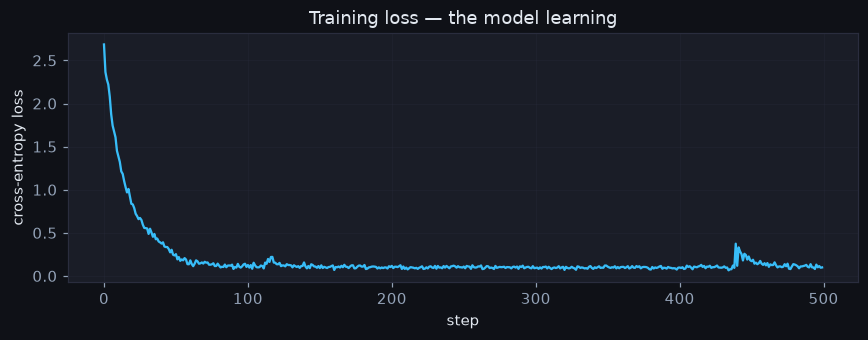

final loss: 0.0990


In [5]:
model = GPT(tok.vocab_size, block_size=16, n_embd=64, n_head=4, n_layer=2, seed=1337)
opt = Adam(model, lr=5e-3)
rng = np.random.default_rng(0)

losses = []
for step in range(500):
    xb, yb = get_batch(data, 16, 32, rng)
    _, loss = model.forward(xb, yb)
    model.backward()
    opt.step()
    losses.append(loss)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(losses, color="#38bdf8")
ax.set(title="Training loss — the model learning", xlabel="step", ylabel="cross-entropy loss")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("final loss:", f"{losses[-1]:.4f}")

---
## 5 · Generate — sample from what it learned

Generation is autoregressive: predict a distribution for the next char, sample one,
append it, feed it back. `temperature` controls randomness — low = confident/repetitive,
high = adventurous/noisier.


In [6]:
def sample(prompt, n=80, temperature=0.8):
    ids = tok.encode(prompt)[None, :]
    out = model.generate(ids, n, np.random.default_rng(1), temperature=temperature)
    return tok.decode(out[0])

for t in (0.5, 0.8, 1.1):
    print(f"[temperature {t}] {sample('to be', 70, t)!r}\n")

[temperature 0.5] 'to be that is the question. to be or not to be that is the question. to be '


[temperature 0.8] 'to be that is the question. to be or not to be that is the question. to be '

[temperature 1.1] 'to be that is e question. to be or not to be that is the question. to be or'



Trained on a repetitive corpus, the model reproduces its structure. Feed it a real book
(swap `text` in §1 for a larger string) and the same code learns real word shapes.

---
## 6 · Look inside — the causal attention pattern

We pull the attention weights out of the first block. Two things to notice:
the strict **lower-triangular** shape (every position attends only to itself and the past —
the causal mask), and how, after training, the weights are no longer uniform: the model
has learned *which* previous characters matter.


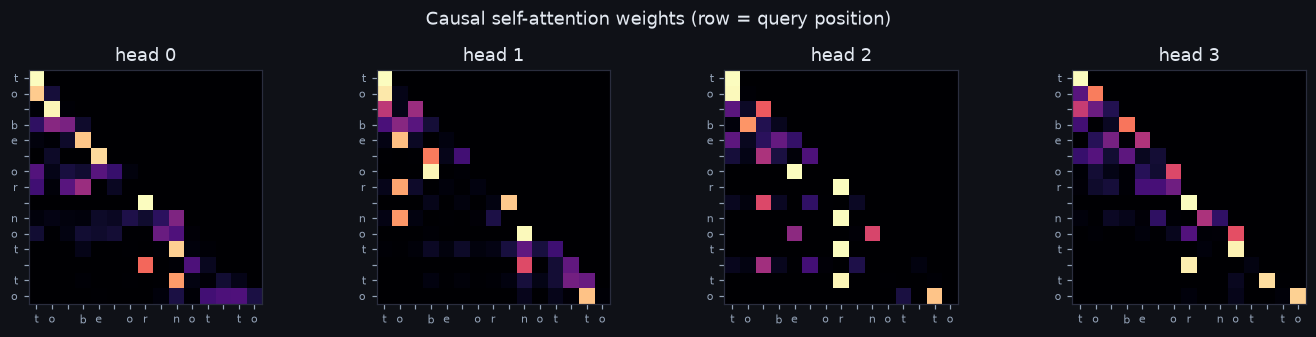

In [7]:
ids = tok.encode("to be or not to")[None, :]
model.forward(ids)                               # populates caches
att = model.sub["blocks"].sub["0"].sub["attn"]._cache[3]   # (B, nh, T, T)

chars = list("to be or not to")
fig, axes = plt.subplots(1, att.shape[1], figsize=(3.2 * att.shape[1], 3.0))
for h, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(att[0, h], cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"head {h}"); ax.set_xticks(range(len(chars)))
    ax.set_yticks(range(len(chars)))
    ax.set_xticklabels(chars, fontsize=7); ax.set_yticklabels(chars, fontsize=7)
fig.suptitle("Causal self-attention weights (row = query position)")
plt.tight_layout(); plt.show()

---
## 7 · Now experiment (this is the point)

The whole reason this is pure NumPy in a notebook is so you can turn knobs and *see* what
each one does. Try these and re-run §4–§6:

| Change | In code | What to watch |
|---|---|---|
| Deeper model | `n_layer=4` | Lower final loss? Slower steps? |
| More context | `block_size=32` | Can it model longer patterns? |
| Fewer heads | `n_head=1` | Does the attention map get less structured? |
| Bigger LR | `lr=2e-2` | Faster fall, or does it diverge? |
| Real text | swap `text` in §1 | Real word shapes emerging |

Break it on purpose: set `n_layer=0`, or remove the `+` residuals in `Block.forward`
(in `nanogpt.py`) and watch training stall — the fastest way to learn *why* a piece exists.


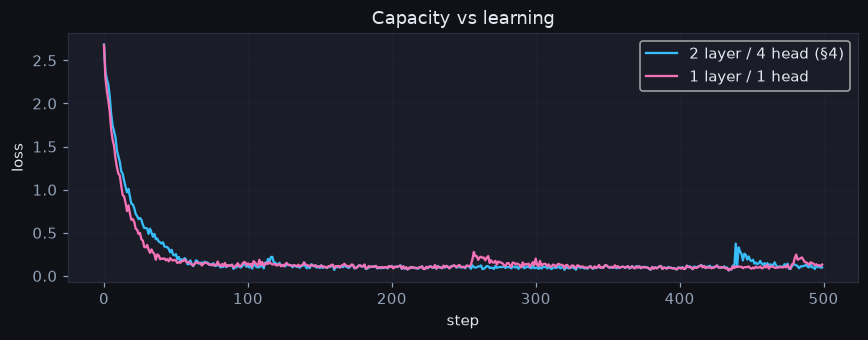

In [8]:
# scratch cell — try a variant and compare its loss curve to §4
m2 = GPT(tok.vocab_size, block_size=16, n_embd=64, n_head=1, n_layer=1, seed=1337)
opt2 = Adam(m2, lr=5e-3); rng2 = np.random.default_rng(0); l2 = []
for _ in range(500):
    xb, yb = get_batch(data, 16, 32, rng2)
    _, loss = m2.forward(xb, yb); m2.backward(); opt2.step(); l2.append(loss)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(losses, color="#38bdf8", label="2 layer / 4 head (§4)")
ax.plot(l2, color="#f472b6", label="1 layer / 1 head")
ax.legend(); ax.grid(alpha=0.3)
ax.set(title="Capacity vs learning", xlabel="step", ylabel="loss")
plt.tight_layout(); plt.show()

---
## 8 · Where this maps to the real world — and what's next

You've now built the thing you deploy at work, from the inside: this is GPT-2's exact
architecture (pre-norm decoder blocks, learned positions), just tiny and in NumPy with
ReLU instead of GELU. Nothing here is a toy *concept* — only a toy *scale*.

**The on-ramp from here (the "builder, not just user" path):**
1. **KV-cache** — at generation time we recompute attention over the whole prefix every
   step. Cache K and V and you recompute only the new token. This is the single biggest
   inference speedup, and the reason `../turbo-quant` (KV compression) matters.
2. **RoPE** — swap learned positions for rotary embeddings (what Llama/most modern LLMs use).
3. **A from-scratch inference engine** — batching, sampling strategies, then paged
   attention / speculative decoding. That's the vLLM-internals project: it turns you from
   someone who *runs* vLLM into someone who can explain *why* it's fast.

Each of those is a natural next subfolder in `learning/` — build to understand, then
share the notebook so the next learner can follow the same path.


---
## 9 · Summary — the whole thing in one table

| Piece | File location | Job |
|---|---|---|
| Char tokenizer | `CharTokenizer` | text ↔ integer tokens |
| Embeddings | `GPT.forward` | token id + position → vector |
| Causal attention | `CausalSelfAttention` | mix info across positions, past-only |
| MLP | `MLP` | per-token processing (most params) |
| Pre-norm block | `Block` | `x+Attn(LN x)`, `x+MLP(LN x)` |
| Loss | `GPT.forward` | softmax cross-entropy on next token |
| Backprop | every `.backward` | hand-written gradients, checked to 1e-5 |
| Optimizer | `Adam` | turn gradients into parameter updates |
| Generation | `GPT.generate` | autoregressive sampling |

**The core idea in one line:** a GPT is next-token prediction trained by backprop —
and you just wrote every gradient yourself.
